In [140]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.utils import plot_model
from IPython.display import Image
import matplotlib.pyplot as plt


In [141]:
!apt-get install graphviz -y
!pip install pydot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [142]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

In [143]:
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [144]:
X_test , X_train , y_test , y_train = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)

In [145]:
model = keras.Sequential([

    keras.layers.Dense(12, activation = "relu",input_shape=(30,)),
    keras.layers.Dense(8,activation = "relu"),
    keras.layers.Dense(1, activation = "sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [146]:
model.compile(
    optimizer ='adam',
    loss = "binary_crossentropy",
    metrics =["accuracy"]
  )

In [134]:
history = model.fit(
    X_train,
    y_train,
    epochs=250,
    validation_split=0.2
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.6264 - loss: 119.0338 - val_accuracy: 0.6087 - val_loss: 143.3145
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6264 - loss: 108.6240 - val_accuracy: 0.6087 - val_loss: 131.1055
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6264 - loss: 100.1871 - val_accuracy: 0.6087 - val_loss: 119.1224
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6264 - loss: 89.9593 - val_accuracy: 0.6087 - val_loss: 107.8123
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6264 - loss: 81.1793 - val_accuracy: 0.6087 - val_loss: 96.6030
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6264 - loss: 72.5209 - val_accuracy: 0.6087 - val_loss: 85.5099
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6264 - loss: 64.3034 - val_accuracy: 0.6087 - val_loss: 74.5001
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6264 - loss: 55.2230 - val_accur

In [135]:
loss , accuracy = model.evaluate(X_train, y_train, verbose = 0)
print(loss)
print(accuracy)

0.11941094696521759
0.9385964870452881


In [136]:
prediction = model.predict(X_test)
for i in range (len(prediction)):
  predicted_values = prediction[i][0]
  predicted_label = 1 if predicted_values > 0.5 else 0
  print(f"Predicted label: {predicted_label}, Actual label: {y_test[i]}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 0
Predicted label: 0, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 1, Actual label: 1
Predicted label: 0, Actual label: 0
Predicted label: 1, Actua

In [137]:
scaler = StandardScaler()
scaler.fit(X_train)

new_patient = np.array([[19.69, 21.25, 130.00, 1203.0, 0.10960, 0.28390, 0.2414, 0.10520, 0.2597, 0.05883,
                         22.54, 16.67, 152.20, 2019.0, 0.1622, 0.6656, 0.7119, 0.2575, 0.6638, 0.17300,
                         0.023, 0.056, 0.0426, 0.050, 0.046, 0.702, 0.230, 0.530, 0.960, 0.250]])
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)

print(prediction)

if prediction[0][0] > 0.5:
  print("Patient is suffering from Breast Cancer")
else:
  print("Patient is not suffering from Breast Cancer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.9709658]]
Patient is suffering from Breast Cancer


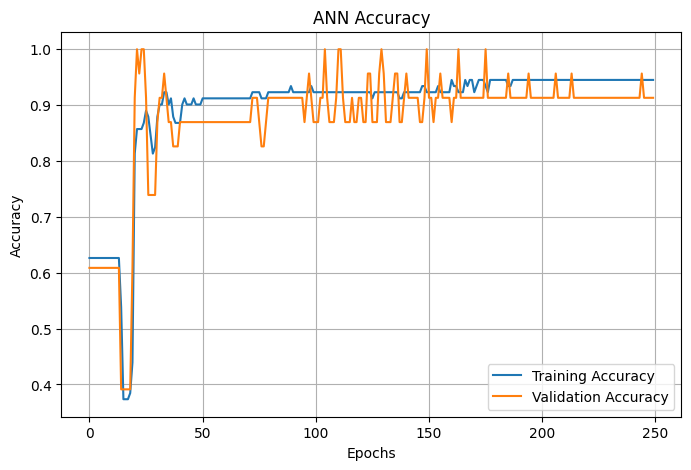

In [147]:


plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('ANN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

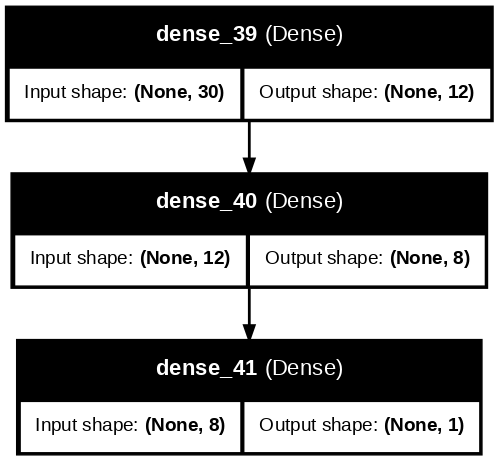

In [148]:


plot_model(
    model,
    to_file='ann_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

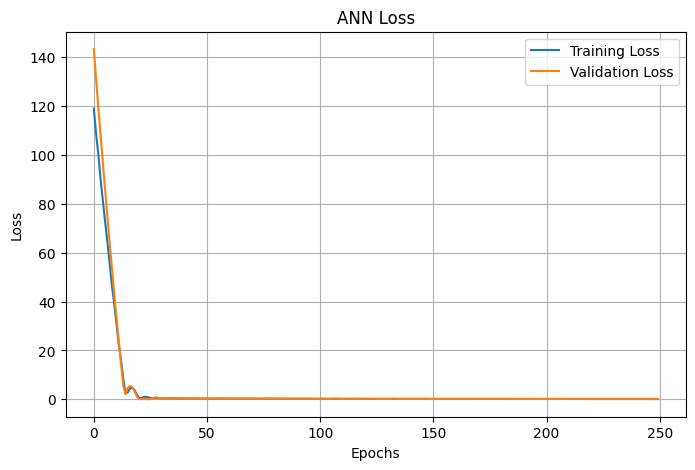

In [149]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('ANN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


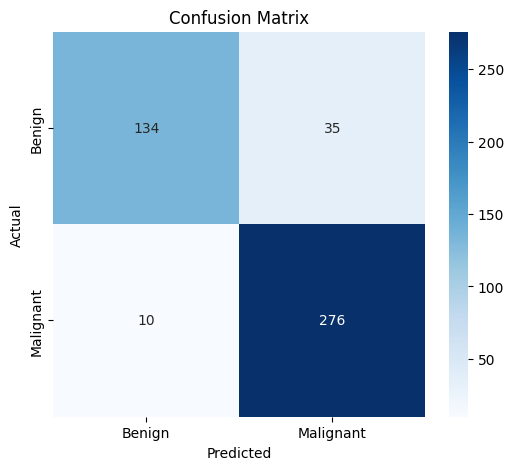

In [150]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign','Malignant'],
    yticklabels=['Benign','Malignant']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


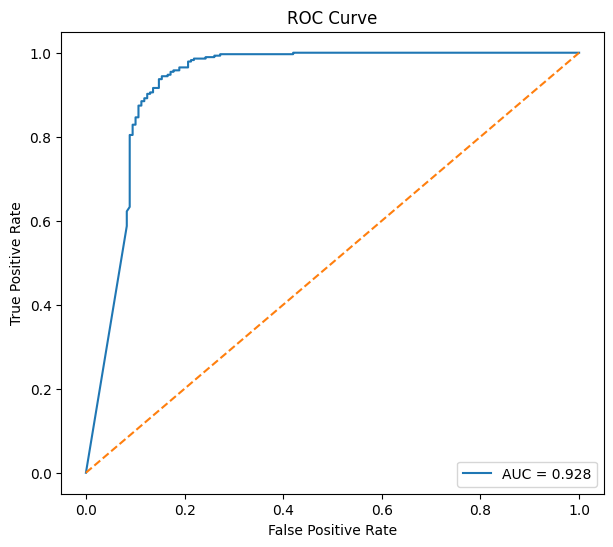

In [151]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_48
Received: inputs=['Tensor(shape=(100, 30))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_48
Received: inputs=['Tensor(shape=(200, 30))']
  warnings.warn(msg)


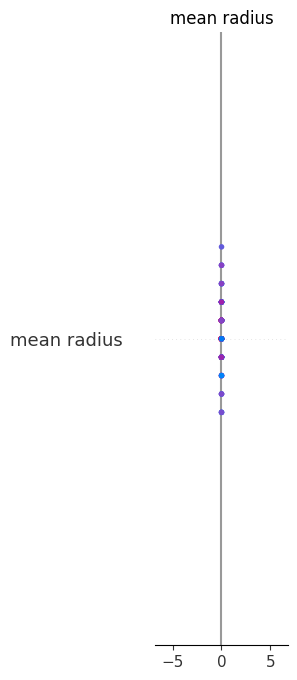

In [152]:
import shap

explainer = shap.DeepExplainer(model, X_train[:100])

shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(
    shap_values,
    X_test[:100],
    feature_names=feature_names
)

In [153]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485 (1.89 KB)

 Trainable params: 485 (1.89 KB)

 Non-trainable params: 0 (0.00 B)